# Exploratory Data Analysis

In [2]:
from pathlib import Path
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt

# Optional (nicer plots)
import seaborn as sns
sns.set(style="whitegrid")

In [4]:
base_dir = Path("data")
train_csv = base_dir / "train.csv"
dev_csv = base_dir / "dev.csv"

## Train set analysis

In [5]:
df = pd.read_csv(train_csv)

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

Shape: (12553, 6)

Columns:
 ['filename', 'transcription', 'spk_id', 'gender', 'ext', 'samplerate']

Data types:
 filename         object
transcription     int64
spk_id           object
gender           object
ext              object
samplerate        int64
dtype: object

Missing values:
 filename         0
transcription    0
spk_id           0
gender           0
ext              0
samplerate       0
dtype: int64


In [7]:
# Basic statistics

print("\nNumerical summary:\n", df.describe())
print("\nCategorical summary:\n", df.describe(include=['object', 'category']))


Numerical summary:
        transcription    samplerate
count   12553.000000  12553.000000
mean   500423.625747  23669.278260
std    288543.897615    731.828661
min        14.000000  22050.000000
25%    251006.000000  24000.000000
50%    497021.000000  24000.000000
75%    749703.000000  24000.000000
max    999888.000000  24000.000000

Categorical summary:
                     filename spk_id  gender    ext
count                  12553  12553   12553  12553
unique                 12553      6       2      1
top     train/0007c21c23.wav  spk_E  female    wav
freq                       1   5686    7665  12553



Top speakers:
 spk_id
spk_E    5686
spk_B    2914
spk_A    1066
spk_C    1063
spk_D     913
spk_F     911
Name: count, dtype: int64


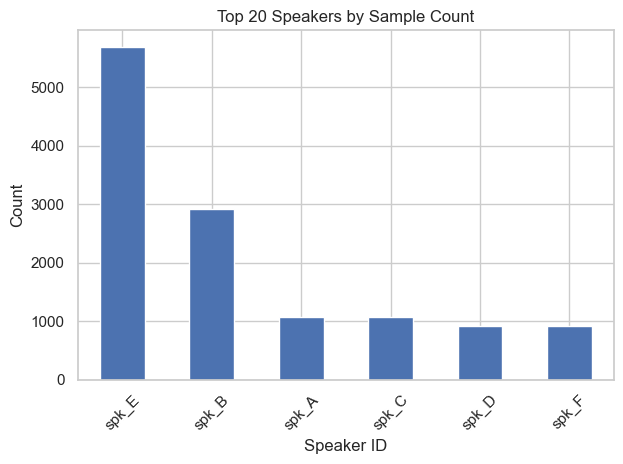

In [11]:
# Speaker-level analysis
speaker_counts = df["spk_id"].value_counts()

print("\nTop speakers:\n", speaker_counts.head(10))

plt.figure()
speaker_counts.head(20).plot(kind="bar")
plt.title("Top 20 Speakers by Sample Count")
plt.xlabel("Speaker ID")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

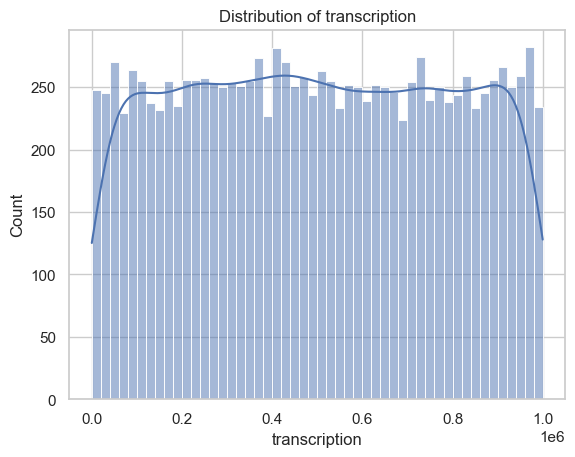

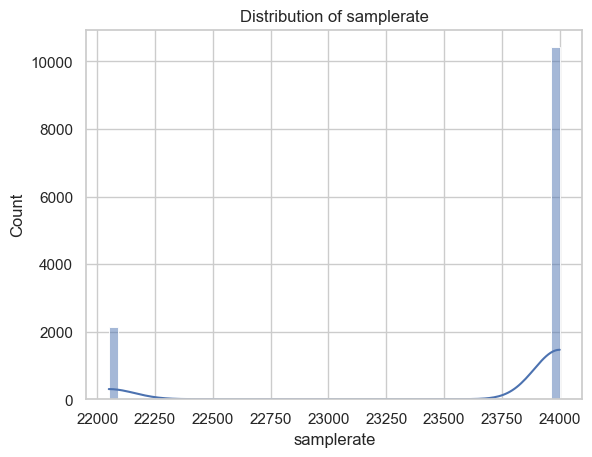

In [12]:
num_cols = df.select_dtypes(include=[np.number]).columns

for col in num_cols:
    plt.figure()
    sns.histplot(df[col].dropna(), bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

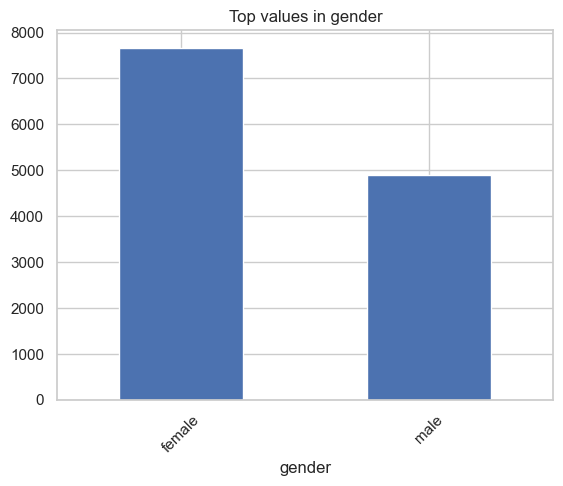

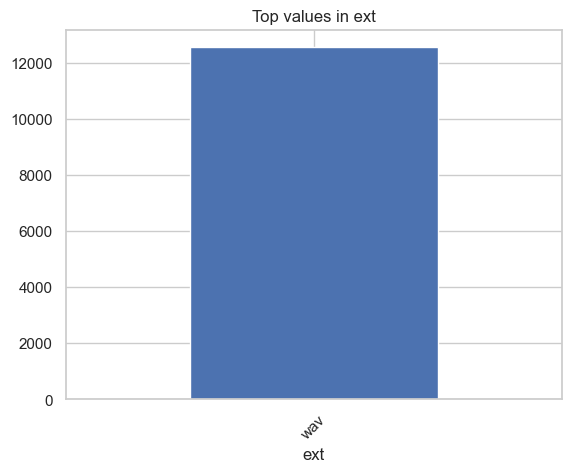

In [15]:
cat_cols = ['gender', 'ext']
for col in cat_cols:
    if col == "speaker_id":
        continue
    top_vals = df[col].value_counts().head(20)

    plt.figure()
    top_vals.plot(kind="bar")
    plt.title(f"Top values in {col}")
    plt.xticks(rotation=45)
    plt.show()

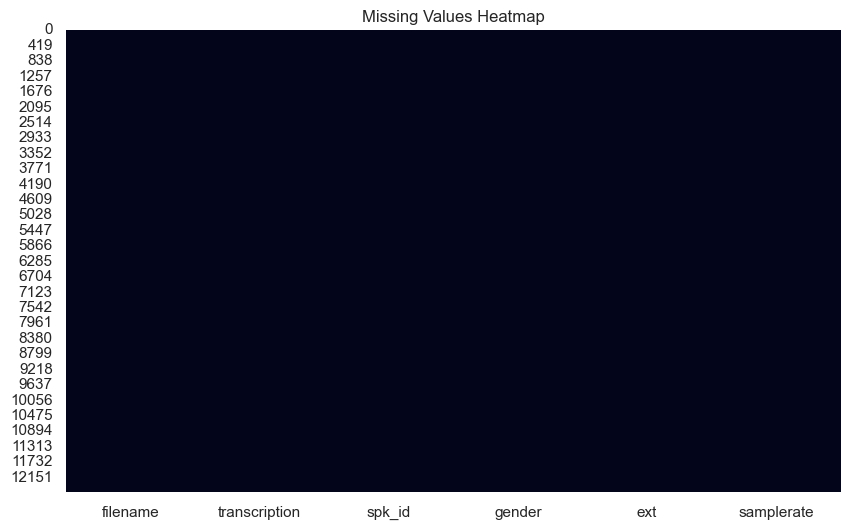

In [19]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

## Dev set analysis

In [20]:
df = pd.read_csv(dev_csv)

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

Shape: (2265, 6)

Columns:
 ['filename', 'transcription', 'spk_id', 'gender', 'ext', 'samplerate']

Data types:
 filename         object
transcription     int64
spk_id           object
gender           object
ext              object
samplerate        int64
dtype: object

Missing values:
 filename         0
transcription    0
spk_id           0
gender           0
ext              0
samplerate       0
dtype: int64


In [21]:
# Basic statistics

print("\nNumerical summary:\n", df.describe())
print("\nCategorical summary:\n", df.describe(include=['object', 'category']))


Numerical summary:
        transcription  samplerate
count    2265.000000      2265.0
mean   503904.978366     16000.0
std    289999.922450         0.0
min      1363.000000     16000.0
25%    251558.000000     16000.0
50%    507286.000000     16000.0
75%    753732.000000     16000.0
max    999669.000000     16000.0

Categorical summary:
                   filename spk_id gender   ext
count                 2265   2265   2265  2265
unique                2265     10      2     2
top     dev/0025d6d9a9.wav  spk_H   male   wav
freq                     1    633   1277  1577



Top speakers:
 spk_id
spk_H    633
spk_I    497
spk_J    344
spk_K    191
spk_F    100
spk_C    100
spk_D    100
spk_B    100
spk_E    100
spk_A    100
Name: count, dtype: int64


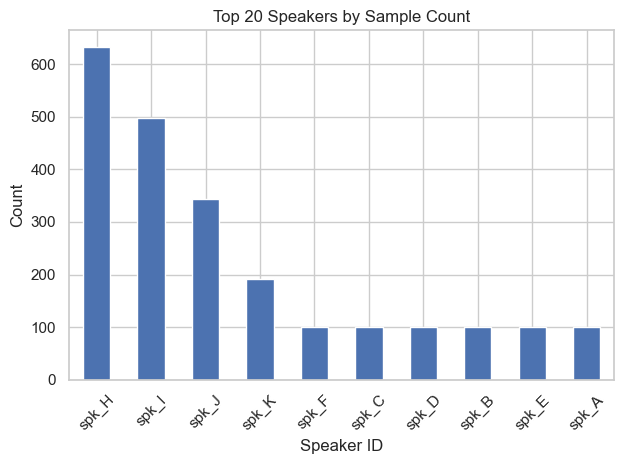

In [22]:
# Speaker-level analysis
speaker_counts = df["spk_id"].value_counts()

print("\nTop speakers:\n", speaker_counts.head(10))

plt.figure()
speaker_counts.head(20).plot(kind="bar")
plt.title("Top 20 Speakers by Sample Count")
plt.xlabel("Speaker ID")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

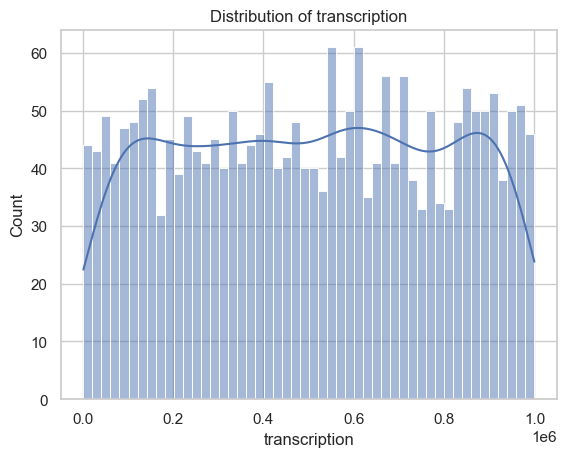

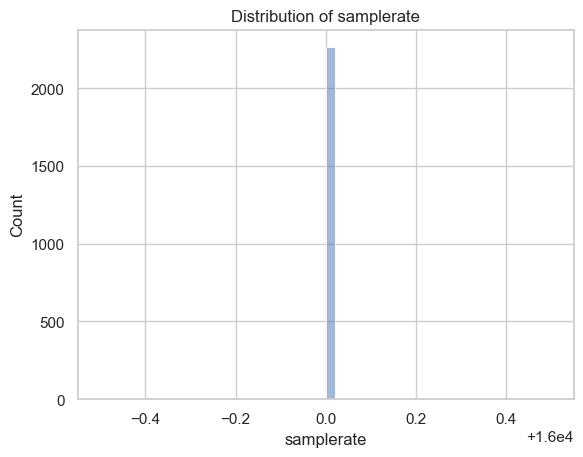

In [23]:
num_cols = df.select_dtypes(include=[np.number]).columns

for col in num_cols:
    plt.figure()
    sns.histplot(df[col].dropna(), bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

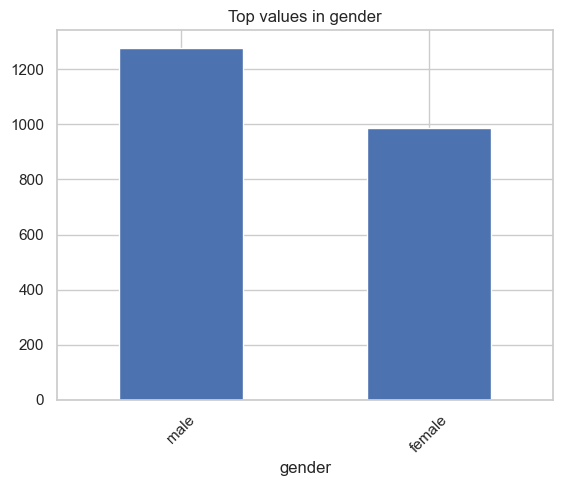

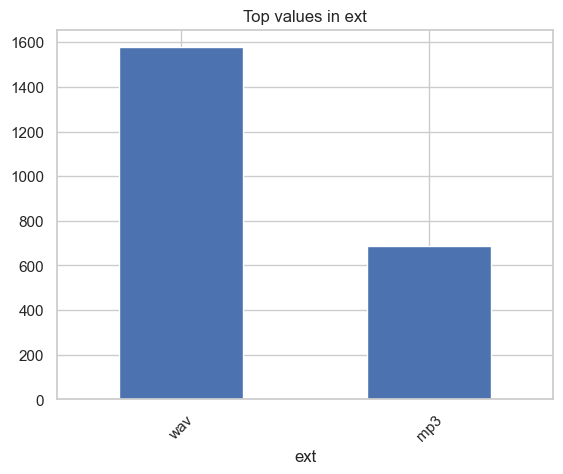

In [24]:
cat_cols = ['gender', 'ext']
for col in cat_cols:
    if col == "speaker_id":
        continue
    top_vals = df[col].value_counts().head(20)

    plt.figure()
    top_vals.plot(kind="bar")
    plt.title(f"Top values in {col}")
    plt.xticks(rotation=45)
    plt.show()

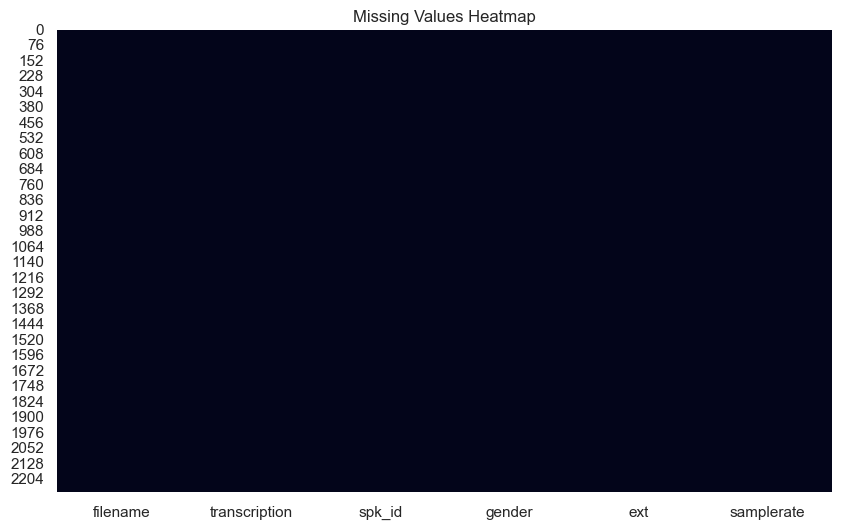

In [25]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

## Summary

### 1. Gender Balance
- Male and Female percentages are approximately equal.

### 2. Transcription Distribution
- Transcription IDs (1_000 to 999_999) are approximately evenly distributed.

### 3. Speaker Imbalance
- **Train set (A–F):** Speakers A, C, D, F have 1000 samples each; speakers B and E show slight imbalance (3k and 6k).
- **Dev set (H–K):** Significantly larger counts than train (H: 633, I: 497, J: 344, K: 191). Severe train-dev speaker mismatch.

### 4. Sample Rate Mismatch
- **Train:** 20k+ Hz
- **Dev:** 16k Hz